In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [3]:
# Load the dataset
df = pd.read_csv('user_behavior_dataset.csv')

print("📊 Dataset Sample:")
print(df.head())

# Extract features
X = df[['Screen On Time (hours/day)']].values
y = df['Battery Drain (mAh/day)'].values

📊 Dataset Sample:
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   

In [4]:
print("📋 Dataset Shape:", df.shape)
print("\n📌 Columns:", df.columns.tolist())
print("\n🔍 Data Types:\n", df.dtypes)
print("\n⚠️ Missing Values:\n", df.isnull().sum())

📋 Dataset Shape: (700, 11)

📌 Columns: ['User ID', 'Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class']

🔍 Data Types:
 User ID                         int64
Device Model                      str
Operating System                  str
App Usage Time (min/day)        int64
Screen On Time (hours/day)    float64
Battery Drain (mAh/day)         int64
Number of Apps Installed        int64
Data Usage (MB/day)             int64
Age                             int64
Gender                            str
User Behavior Class             int64
dtype: object

⚠️ Missing Values:
 User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age         

In [5]:
print("📈 Basic Statistics:")
df[['Screen On Time (hours/day)', 'Battery Drain (mAh/day)']].describe()

📈 Basic Statistics:


,Screen On Time (hours/day),Battery Drain (mAh/day)
count,700.000000,700.000000
mean,5.272714,1525.158571
std,3.068584,819.136414
min,1.000000,302.000000
25%,2.500000,722.250000
50%,4.900000,1502.500000
75%,7.400000,2229.500000
max,12.000000,2993.000000


C:\Users\amand\AppData\Local\Temp\ipykernel_16556\1993117251.py:13: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\amand\AppData\Local\Temp\ipykernel_16556\1993117251.py:13: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


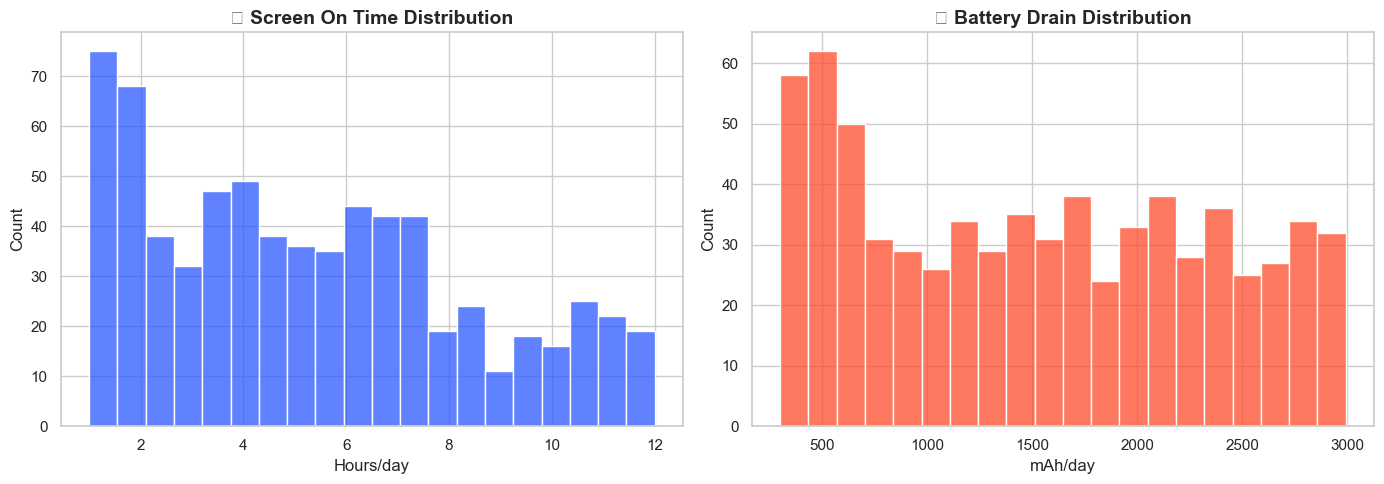

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Screen On Time (hours/day)'], bins=20, color='#2b58ff', edgecolor='white', ax=axes[0])
axes[0].set_title('📱 Screen On Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hours/day', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

sns.histplot(df['Battery Drain (mAh/day)'], bins=20, color='#ff4b2b', edgecolor='white', ax=axes[1])
axes[1].set_title('🔋 Battery Drain Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('mAh/day', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

🔗 Correlation Matrix:
                            Screen On Time (hours/day)  \
Screen On Time (hours/day)                    1.000000   
Battery Drain (mAh/day)                       0.948983   

                            Battery Drain (mAh/day)  
Screen On Time (hours/day)                 0.948983  
Battery Drain (mAh/day)                    1.000000  


C:\Users\amand\AppData\Local\Temp\ipykernel_16556\4074414915.py:8: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


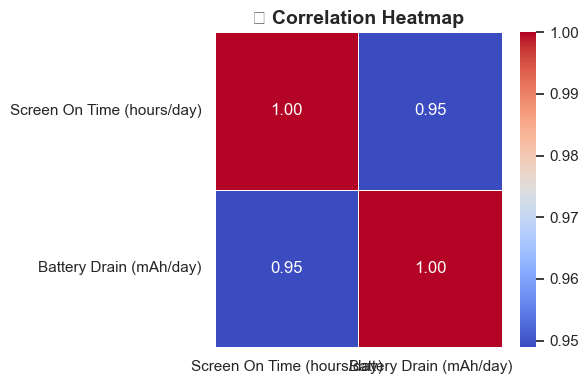

In [7]:
corr = df[['Screen On Time (hours/day)', 'Battery Drain (mAh/day)']].corr()
print("🔗 Correlation Matrix:")
print(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('📊 Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


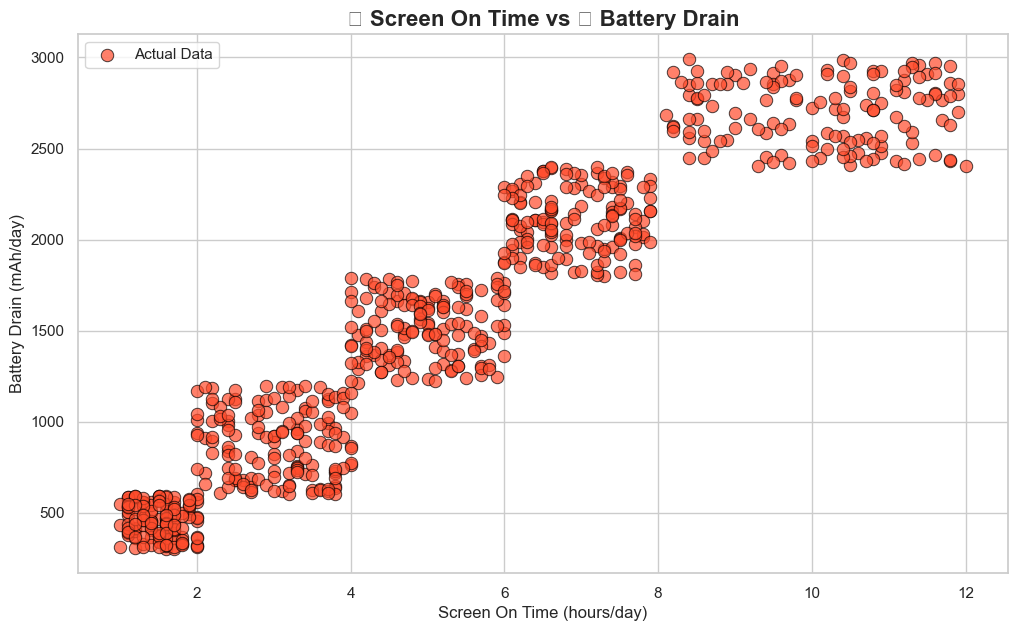

In [8]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    x=df['Screen On Time (hours/day)'],
    y=df['Battery Drain (mAh/day)'],
    color='#ff4b2b', s=80, edgecolor='black', alpha=0.7, label='Actual Data'
)

plt.title('📱 Screen On Time vs 🔋 Battery Drain', fontsize=16, fontweight='bold')
plt.xlabel('Screen On Time (hours/day)', fontsize=12)
plt.ylabel('Battery Drain (mAh/day)', fontsize=12)
plt.legend()
plt.show()

In [9]:
X = df[['Screen On Time (hours/day)']]
y = df['Battery Drain (mAh/day)']

print("✅ Features and target ready.")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

✅ Features and target ready.
   X shape: (700, 1)
   y shape: (700,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split successfully.")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")

✅ Data split successfully.
   Training samples : 560
   Testing samples  : 140


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully.")
print(f"\n📐 Slope (coefficient) : {model.coef_[0]:.4f}")
print(f"📐 Intercept           : {model.intercept_:.4f}")
print(f"\n🧮 Formula: Battery Drain = {model.coef_[0]:.4f} × Screen On Time + {model.intercept_:.4f}")

✅ Linear Regression model trained successfully.

📐 Slope (coefficient) : 254.4492
📐 Intercept           : 184.1367

🧮 Formula: Battery Drain = 254.4492 × Screen On Time + 184.1367


In [12]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"📊 MAE  : {mae:.2f}")
print(f"📊 MSE  : {mse:.2f}")
print(f"📊 RMSE : {rmse:.2f}")
print(f"📊 R²   : {r2:.4f}")

📊 MAE  : 205.78
📊 MSE  : 66751.94
📊 RMSE : 258.36
📊 R²   : 0.8924


c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


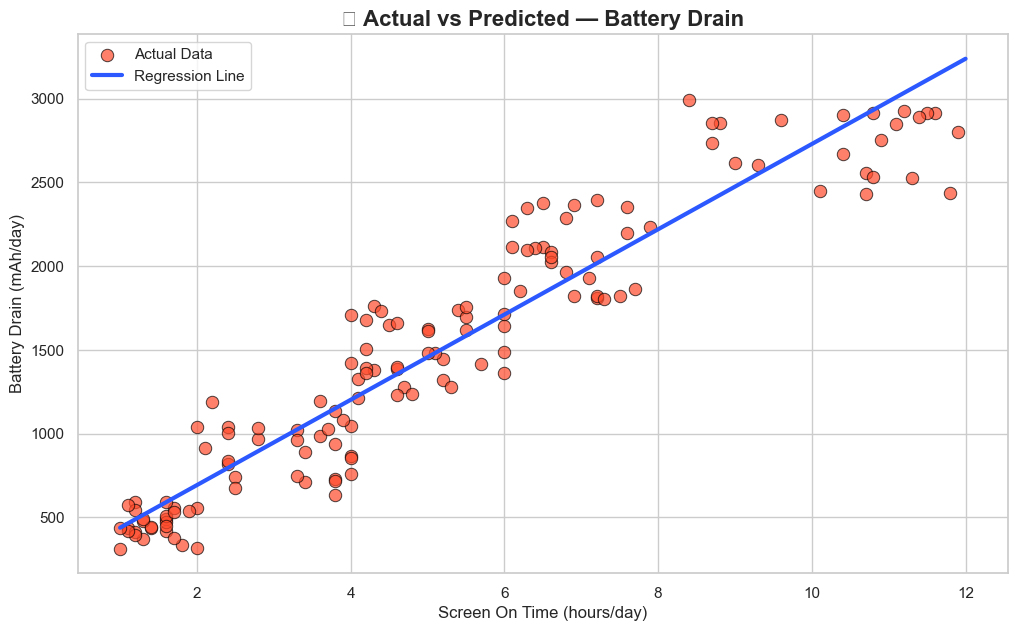

In [13]:
plt.figure(figsize=(12, 7))

sns.scatterplot(x=X_test['Screen On Time (hours/day)'], y=y_test,
                color='#ff4b2b', s=80, edgecolor='black', alpha=0.7, label='Actual Data')

X_range = np.linspace(X['Screen On Time (hours/day)'].min(),
                      X['Screen On Time (hours/day)'].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(X_range)
plt.plot(X_range, y_range_pred, color='#2b58ff', linewidth=3, label='Regression Line')

plt.title('🔋 Actual vs Predicted — Battery Drain', fontsize=16, fontweight='bold')
plt.xlabel('Screen On Time (hours/day)', fontsize=12)
plt.ylabel('Battery Drain (mAh/day)', fontsize=12)
plt.legend()
plt.show()

C:\Users\amand\AppData\Local\Temp\ipykernel_16556\2601463381.py:10: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


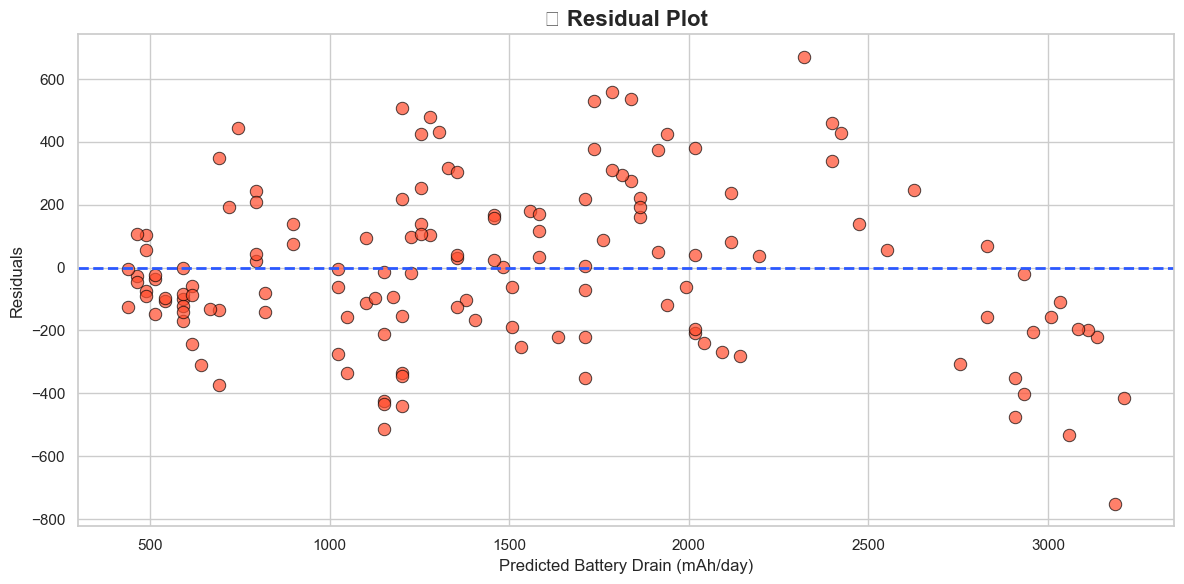

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred, y=residuals, color='#ff4b2b', s=80, edgecolor='black', alpha=0.7)
plt.axhline(0, color='#2b58ff', linewidth=2, linestyle='--')

plt.title('📉 Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Battery Drain (mAh/day)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
test_values = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]

results = pd.DataFrame({
    'Screen On Time (hrs)': test_values,
    'Predicted Battery Drain (mAh)': [round(model.predict([[v]])[0], 2) for v in test_values]
})

print("📋 Prediction Table:")
print(results.to_string(index=False))

📋 Prediction Table:
 Screen On Time (hrs)  Predicted Battery Drain (mAh)
                  1.0                         438.59
                  2.0                         693.04
                  3.0                         947.48
                  4.0                        1201.93
                  5.0                        1456.38
                  6.0                        1710.83
                  7.0                        1965.28
                  8.0                        2219.73
                  9.0                        2474.18
                 10.0                        2728.63
                 11.0                        2983.08
                 12.0                        3237.53


c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Line

In [16]:
def predict_battery_drain(screen_hours):
    prediction = model.predict([[screen_hours]])[0]
    print(f"\n🔮 Prediction for Screen On Time = {screen_hours} hrs/day:")
    print(f"   Estimated Battery Drain: {prediction:,.2f} mAh/day")

# Input from user
try:
    user_hours = float(input("Enter Screen On Time (hours/day): "))
    predict_battery_drain(user_hours)
except ValueError:
    print("❌ Invalid input! Please enter a numeric value.")


🔮 Prediction for Screen On Time = 10.0 hrs/day:
   Estimated Battery Drain: 2,728.63 mAh/day


c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
